In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Beolvasás és magyar adatok kiválogatása
dataset = pd.read_csv("survey_results_public.csv")
dataset_hungary = dataset.loc[dataset["Country"] == "Hungary"]
dataset_hungary.value_counts(dataset_hungary["Country"],dropna=False)
del dataset

In [3]:
# Üres sorok kitörlése
dataset_hungary.dropna(subset=["LanguageHaveWorkedWith"],inplace=True)

In [4]:
# Ahol egy sorban több programnyelv van felsorolva, ott a sorokat szét kell választani, és a kapott tömböt több sorba kell tenni
dataset_hungary["LanguageHaveWorkedWith"] = dataset_hungary["LanguageHaveWorkedWith"].str.split(';')
dataset_hungary = dataset_hungary.explode("LanguageHaveWorkedWith").reset_index(drop=True)

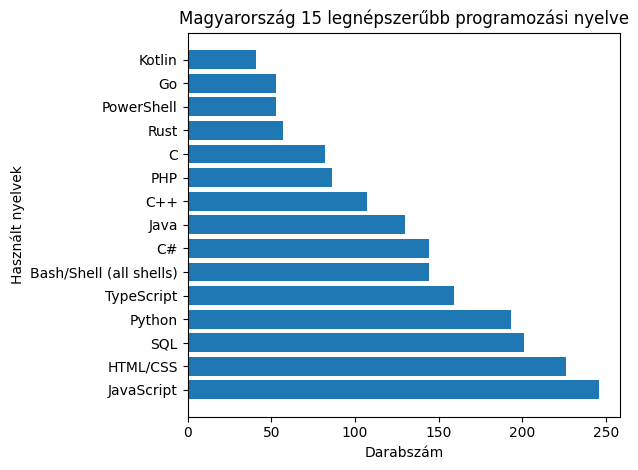

In [6]:
# Tengelyek
ax = plt.subplot()

# 15 leghasználtabb nyelv
counts = dataset_hungary["LanguageHaveWorkedWith"].value_counts().head(15)

# a value_counts() visszad egy index és egy values értéket, jelenesetben a nyelveket és a darabszámokat
nyelvek = counts.index
darabszam = counts.values

# Tengelyek megadása
ax.barh(nyelvek,darabszam)

# Tengelyek elnevezése
ax.set_xlabel("Darabszám")
ax.set_ylabel("Használt nyelvek")
ax.set_title("Magyarország 15 legnépszerűbb programozási nyelve")

# tight_layout() elrendezi a vásznon az értékeket
plt.tight_layout()
plt.show()
